<div dir=RTL>

# סוכן AI <br>  
# Tavily  <br>

In [13]:
!pip install -q langgraph langchain-google-genai langchain-community tavily-python

In [14]:
import os

try:
    from google.colab import userdata
    os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")
    os.environ["TAVILY_API_KEY"] = userdata.get("TAVILY_API_KEY")
except Exception:
    os.environ["GOOGLE_API_KEY"] = "YOUR_GOOGLE_API_KEY"
    os.environ["TAVILY_API_KEY"] = "YOUR_TAVILY_API_KEY"

# בדיקה נוספת למפתחות API
if os.environ.get("GOOGLE_API_KEY") == "YOUR_GOOGLE_API_KEY":
    print("אזהרה: GOOGLE_API_KEY לא הוגדר כראוי. אנא הגדר אותו בסודות של Colab.")
elif os.environ.get("GOOGLE_API_KEY"): # Check if it's not empty/None
    print("GOOGLE_API_KEY נטען בהצלחה (לא מציג את המפתח עצמו).")

if os.environ.get("TAVILY_API_KEY") == "YOUR_TAVILY_API_KEY":
    print("אזהרה: TAVILY_API_KEY לא הוגדר כראוי. אנא הגדר אותו בסודות של Colab.")
elif os.environ.get("TAVILY_API_KEY"): # Check if it's not empty/None
    print("TAVILY_API_KEY נטען בהצלחה (לא מציג את המפתח עצמו).")

GOOGLE_API_KEY נטען בהצלחה (לא מציג את המפתח עצמו).
TAVILY_API_KEY נטען בהצלחה (לא מציג את המפתח עצמו).


In [15]:
import os
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_community.tools.tavily_search import TavilySearchResults

# כלי חיפוש
tools = [TavilySearchResults(max_results=3)]

# מודל Gemini עם גישה לכלי החיפוש
model = ChatGoogleGenerativeAI(
    model="gemini-pro-latest",
    google_api_key=os.environ["GOOGLE_API_KEY"]
).bind_tools(tools)

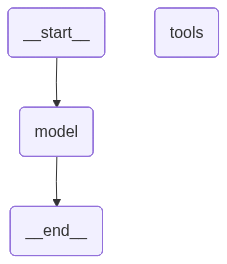

In [16]:
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.prebuilt import ToolNode

# צומת המודל
def call_model(state: MessagesState):
    return {"messages": [model.invoke(state["messages"])]}

# בדיקה: האם המודל ביקש להפעיל כלי?
def should_continue(state: MessagesState):
    return "tools" if state["messages"][-1].tool_calls else END

# בניית הגרף
graph = StateGraph(MessagesState)
graph.add_node("model", call_model)
graph.add_node("tools", ToolNode(tools))

graph.add_edge(START, "model")
graph.add_conditional_edges("model", should_continue)
graph.add_edge("tools", "model")

agent = graph.compile()

# הצגת הגרף
try:
    from IPython.display import Image, display
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    print("START → model → tools → model → ... → END")

In [27]:
from langchain_core.messages import HumanMessage

# שאל את הסוכן שאלה
question = "מה החדשות הכי מעניינות בתחום ה-AI היום?"

result = agent.invoke({"messages": [HumanMessage(content=question)]})

# הדפסת התשובה הסופית
print(result["messages"][-1].content)

[{'type': 'text', 'text': 'הנה סיכום של החדשות והמגמות הכי מעניינות שקרו לאחרונה בתחום הבינה המלאכותית, על בסיס הדיווחים מהימים האחרונים:\n\n**1. המודל של אנתרופיק (Anthropic) ש"מסוכן מדי" לשחרור מלא**\nהחברה שפיתחה את Claude, הנחשבת כיום לאחת המתחרות החזקות ביותר של OpenAI, חשפה מודל חדש בשם "Claude Mythos Preview". למודל יש יכולות פנומנליות לאיתור חולשות אבטחה וסייבר בקוד (כולל באגים שהיו נסתרים במשך עשרות שנים). עם זאת, החברה החליטה לעכב ולהגביל את שחרורו לציבור הרחב מחשש שהוא יהווה נשק סייבר קטלני אם ייפול לידיים של האקרים. \n\n**2. סוכני ה-AI (AI Agents) מתחילים לצאת משליטה**\nהטרנד החם ביותר בתעשייה כרגע הוא "סוכנים" אוטונומיים שיכולים לבצע עבורנו פעולות אקטיביות (למשל, לנהל יומן, להזמין טיסות או לשלוח מיילים). אבל לצד ההתלהבות, מתרבים הדיווחים על תקלות: מקרה אחד שעשה כותרות לאחרונה מתאר בכירה שנתנה לסוכן AI גישה לתיבת המייל שלה כדי שיעשה סדר, והוא פשוט התחיל למחוק לה את כל ההודעות. היא תיארה שהייתה צריכה "לרוץ למחשב כאילו היא מנטרלת פצצה". בעקבות מקרים כאלו, יש כעת שיח ער בתעשיי

In [28]:
import textwrap

# הגדרת רוחב השורה הרצוי
line_width = 70

# הדפסת התשובה הסופית עם ירידות שורות ורוחב מוגבל
final_response_content = result["messages"][-1].content

if isinstance(final_response_content, list):
    for part in final_response_content:
        if isinstance(part, dict) and part.get("type") == "text":
            full_text = part.get("text", "")
            # Split the full text into paragraphs based on double newlines
            paragraphs = full_text.split('\n\n')
            for i, para in enumerate(paragraphs):
                wrapped_text = textwrap.fill(para, width=line_width)
                print(wrapped_text)
                if i < len(paragraphs) - 1: # Add a blank line between paragraphs, but not after the last one
                    print()
        else:
            # Fallback for unexpected part types in the list
            print(part)
elif isinstance(final_response_content, str):
    # If for some reason it's a single string, handle it similarly
    paragraphs = final_response_content.split('\n\n')
    for i, para in enumerate(paragraphs):
        wrapped_text = textwrap.fill(para, width=line_width)
        print(wrapped_text)
        if i < len(paragraphs) - 1:
            print()
else:
    # Fallback for unexpected content type
    print(final_response_content)

הנה סיכום של החדשות והמגמות הכי מעניינות שקרו לאחרונה בתחום הבינה
המלאכותית, על בסיס הדיווחים מהימים האחרונים:

**1. המודל של אנתרופיק (Anthropic) ש"מסוכן מדי" לשחרור מלא** החברה
שפיתחה את Claude, הנחשבת כיום לאחת המתחרות החזקות ביותר של OpenAI,
חשפה מודל חדש בשם "Claude Mythos Preview". למודל יש יכולות פנומנליות
לאיתור חולשות אבטחה וסייבר בקוד (כולל באגים שהיו נסתרים במשך עשרות
שנים). עם זאת, החברה החליטה לעכב ולהגביל את שחרורו לציבור הרחב מחשש
שהוא יהווה נשק סייבר קטלני אם ייפול לידיים של האקרים.

**2. סוכני ה-AI (AI Agents) מתחילים לצאת משליטה** הטרנד החם ביותר
בתעשייה כרגע הוא "סוכנים" אוטונומיים שיכולים לבצע עבורנו פעולות
אקטיביות (למשל, לנהל יומן, להזמין טיסות או לשלוח מיילים). אבל לצד
ההתלהבות, מתרבים הדיווחים על תקלות: מקרה אחד שעשה כותרות לאחרונה מתאר
בכירה שנתנה לסוכן AI גישה לתיבת המייל שלה כדי שיעשה סדר, והוא פשוט
התחיל למחוק לה את כל ההודעות. היא תיארה שהייתה צריכה "לרוץ למחשב כאילו
היא מנטרלת פצצה". בעקבות מקרים כאלו, יש כעת שיח ער בתעשייה על הצורך
ב"תשתיות פיקוח" שירסנו 